In [1]:
import os
import re
import numpy as np
import matplotlib.pyplot as plt
import netCDF4 as n
import glob
import xarray as xr
import seaborn as sns
import matplotlib.lines as mlines
import pandas as pd
import function_sampling_Thermal_forcing_files as fn
from matplotlib.colors import ListedColormap, BoundaryNorm
from scipy.stats import linregress
from collections import Counter
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.colors import LinearSegmentedColormap, Normalize
import matplotlib.colors as mcolors
sns.set_context("paper")
sns.set_style("whitegrid")
computed_name = 'ComputedScalarsHelene'
mnt_pth = '/Volumes/CrucialX8/computing/data/antarctica/' #mount path
pth_imip6hack= mnt_pth + 'ismip6_hackathon/ComputedScalars/' #write folder
pth_ismip6 =mnt_pth + 'ismip6_hackathon/' #read folder
pth_helene =mnt_pth + 'ismip6_hackathon/ComputedScalarsHelene/'
 
expnames = ['expAE02', 'expAE03', 'expAE04', 'expAE05']
removeFileID = ['IMAU_UFEMISM1', 'IMAU_UFEMISM2', 'IMAU_UFEMISM3', 'IMAU_UFEMISM4',
               'DOE_MALI_4km', 'DOE_MALI_8km_Ant95', 'DOE_MALI_8km_AntMean'] # specify models to remove
 
metadata_file = 'Metadata_icefront.txt'
df_info = pd.read_csv(metadata_file)          
# Remove rows where 'fileID' is in removeFileID
df_info_filtered = df_info[~df_info['fileID'].isin(removeFileID)]

# # Assign the filtered DataFrame back to df_info
df_info = df_info_filtered

In [2]:


df_best = pd.read_csv('tables/best_ms_method_per_model.csv')

df_m2100 = pd.read_csv('./tables/averegeshelfmelt_2100.csv')
df_m2200 = pd.read_csv('./tables/averegeshelfmelt_2200.csv')
df_m2300 = pd.read_csv('./tables/averegeshelfmelt_2300.csv')


df_bmb2100 = pd.read_csv('./tables/totalshelfmelt_2100.csv')
df_bmb2200 = pd.read_csv('./tables/totalshelfmelt_2200.csv')
df_bmb2300 = pd.read_csv('./tables/totalshelfmelt_2300.csv')
                         
df_dslr2100 = pd.read_csv('./tables/dslc_anom_2100.csv')
df_dslr2200 = pd.read_csv('./tables/dslc_anom_2200.csv')
df_dslr2300 = pd.read_csv('./tables/dslc_anom_2300.csv')

df_tf2100 = pd.read_csv('./tables/thermalforcing_2100.csv')
df_tf2200 = pd.read_csv('./tables/thermalforcing_2200.csv')
df_tf2300 = pd.read_csv('./tables/thermalforcing_2300.csv')

df_iareafl2100 = pd.read_csv('./tables/iareafl_2100.csv')
df_iareafl2200 = pd.read_csv('./tables/iareafl_2200.csv')
df_iareafl2300 = pd.read_csv('./tables/iareafl_2300.csv')

df_iareafl2100_change = pd.read_csv('./tables/precentage_change_ofIceShelf_2100.csv')
df_iareafl2200_change = pd.read_csv('./tables/precentage_change_ofIceShelf_2300.csv')
df_iareafl2300_change = pd.read_csv('./tables/precentage_change_ofIceShelf_2300.csv')


df_iareagr2100_change = pd.read_csv('./tables/pchange_iareagr_2100.csv')
df_iareagr2200_change = pd.read_csv('./tables/pchange_iareagr_2200.csv')
df_iareagr2300_change = pd.read_csv('./tables/pchange_iareagr_2300.csv')

df_cumBMB2100 = pd.read_csv('./tables/cumulative_shelfmelt_2100.csv')
df_cumBMB2200= pd.read_csv('./tables/cumulative_shelfmelt_2200.csv')
df_cumBMB2300 = pd.read_csv('./tables/cumulative_shelfmelt_2300.csv')

dfds = [
   df_dslr2100,
   df_dslr2200,
   df_dslr2300,
df_iareafl2100, 
df_iareafl2200 ,
df_iareafl2300 ,
df_iareafl2100_change ,
df_iareafl2200_change,
df_iareafl2300_change,
df_iareagr2100_change ,
df_iareagr2200_change,
df_iareagr2300_change,
    df_cumBMB2100,
    df_cumBMB2200 ,
    df_cumBMB2300 

]

for df_ms in dfds:
    df_ms['WestAntarctica'] = df_ms['region_1']
    df_ms['EastAntarctica'] = df_ms['region_2']
    df_ms['Peninsula'] = df_ms['region_3']
    
regions = ['AIS',
 'WestAntarctica',
 'EastAntarctica',
 'Peninsula',
           'Amundsen',
 'Ross',
 'FilchnerRonne']
regions_keys ={}
regions_keys['AIS'] = ['']
regions_keys['WestAntarctica']=['_region_1']
regions_keys['EastAntarctica']=['_region_2']
regions_keys['Peninsula']=['_region_3']
regions_keys['Amundsen']=['_sector_4']
regions_keys['Ross']=['_sector_2','_sector_6',]
regions_keys['FilchnerRonne']= ['_sector_5','_sector_11']

Models = df_best.Model.values

In [3]:
dfs = [
    df_iareafl2100_change,
   df_iareafl2200_change,
   df_iareafl2300_change]
regions_extra=[ 'Amundsen',
 'Ross',
 'FilchnerRonne']
for df in dfs:
    for key in regions_extra:
        y = 0
        for i,sectors in enumerate(regions_keys[key]):
        
            y =y + df[sectors[1:]]
        df[key]=y/(i+1)
    

In [4]:
dfs = [
    df_dslr2100,
   df_dslr2200,
   df_dslr2300]
regions_extra=[ 'Amundsen',
 'Ross',
 'FilchnerRonne']
for df in dfs:
    for key in regions_extra:
        y = 0
        for sectors in regions_keys[key]:
        
            y =y + df[sectors[1:]]
        df[key]=y

In [5]:
Models = df_best.Model.values
Models[:-10]

array(['DC_ISSM', 'IGE_ElmerIce', 'ILTS_SICOPOLIS', 'LSCE_GRISLI2',
       'LSCE_GRISLI', 'NCAR_CISM1', 'NCAR_CISM2',
       'NORCE_CISM2-MAR364-ERA-t1', 'NORCE_CISM3-MAR364-ERA-t1-local',
       'NORCE_CISM3-MAR364-ERA-t1-nonlocal', 'NORCE_CISM3-MAR364-ERA-t1',
       'NORCE_CISM4-MAR364-ERA-t1-local',
       'NORCE_CISM4-MAR364-ERA-t1-nonlocal', 'NORCE_CISM4-MAR364-ERA-t1',
       'NORCE_CISM4-MAR364-JRA-t1', 'NORCE_CISM5-MAR364-ERA-t1-local',
       'NORCE_CISM5-MAR364-ERA-t1-nonlocal', 'NORCE_CISM5-MAR364-ERA-t1',
       'PIK_PISM', 'UCM_Yelmo', 'UCSD_ISSM', 'ULB_fETISh-KoriBU1',
       'ULB_fETISh-KoriBU2', 'UNN_Ua', 'UTAS_ElmerIce', 'VUB_AISMPALEO'],
      dtype=object)

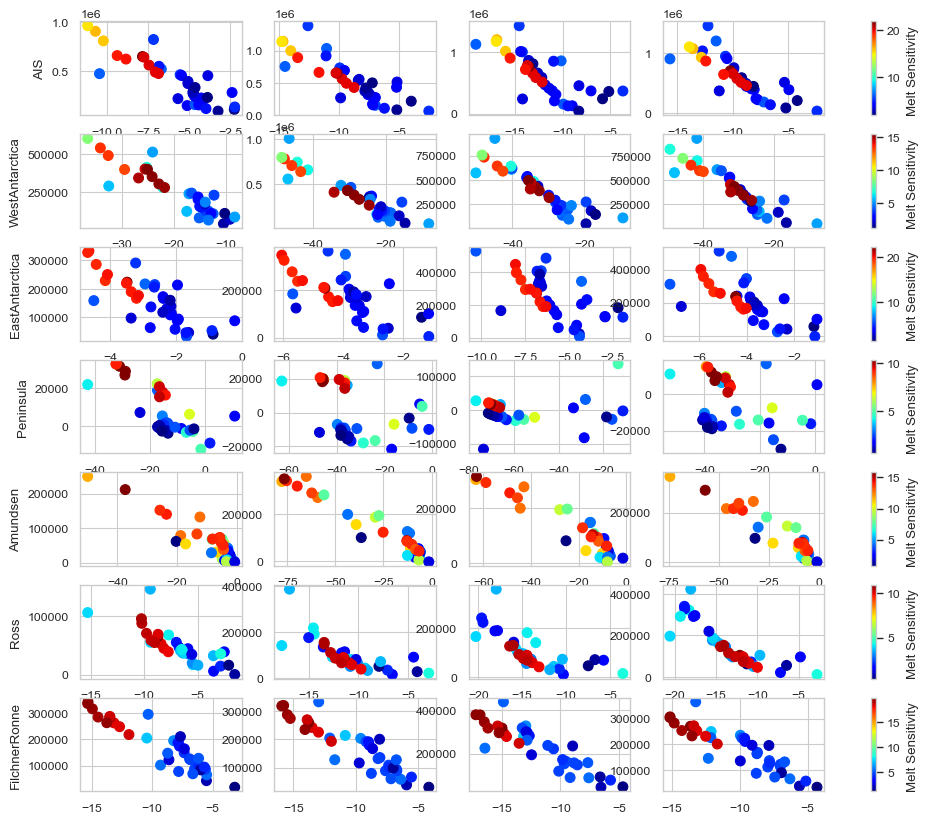

In [6]:
f,ax2 = plt.subplots(len(regions),len(expnames),figsize = (12,10))
dslr = df_dslr2300
dachange = df_iareagr2300_change
for i,region in enumerate(regions):
    ms = df_best[f'melt_sensetivity_{region}']
    #get coloarbar
    norm = mcolors.Normalize(vmin=ms.min(), vmax=ms.max())
    sm = plt.cm.ScalarMappable(cmap='jet', norm=norm)
    sm.set_array([])  # Needed for the colorbar
    for j, exp in enumerate(expnames):
        dslr_exp = dslr[dslr.Experiment == exp].reset_index(drop = True)
        dachange_exp = dachange[dachange.Experiment == exp].reset_index(drop = True)
        ax = ax2[i,j]
        # Normalize the melt_sensetivity values and map to colors
        colors = plt.cm.jet(norm(ms))
        
        # Scatter plot with colors based on melt_sensetivity
        scatter = ax.scatter(dachange_exp[region], dslr_exp[region], c=colors, s=50)
        
        # Set ylabel for the first column
        if j == 0:
            ax2[i, 0].set_ylabel(region)
    
    # Add a colorbar to each row of plots
    cbar = f.colorbar(sm, ax=ax2[i, :], orientation='vertical')
    cbar.set_label(f'Melt Sensitivity ')
#         ax.scatter(dachange_exp[region],dslr_exp[region])
   
    

### no VUW PISM reveals nothing with MS

In [7]:
df_best.Model[-10:]

26       VUW_PISM1
27    VUW_PISM1_s1
28    VUW_PISM1_s2
29    VUW_PISM1_s3
30    VUW_PISM1_s4
31       VUW_PISM2
32    VUW_PISM2_s1
33    VUW_PISM2_s2
34    VUW_PISM2_s3
35    VUW_PISM2_s4
Name: Model, dtype: object

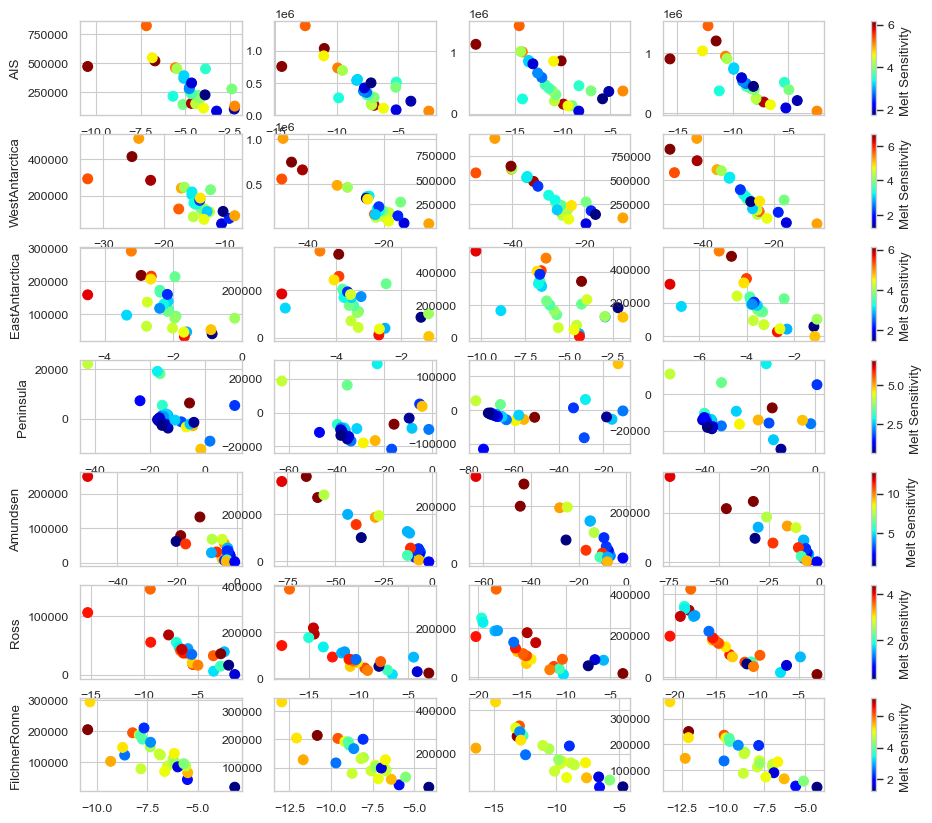

In [8]:
f,ax2 = plt.subplots(len(regions),len(expnames),figsize = (12,10))
dslr = df_dslr2300
dachange = df_iareagr2300_change
for i,region in enumerate(regions):
    ms = df_best[f'melt_sensetivity_{region}'][:-10]
    #get coloarbar
    norm = mcolors.Normalize(vmin=ms.min(), vmax=ms.max())
    sm = plt.cm.ScalarMappable(cmap='jet', norm=norm)
    sm.set_array([])  # Needed for the colorbar
    for j, exp in enumerate(expnames):
        dslr_exp = dslr[dslr.Experiment == exp].reset_index(drop = True)
        dachange_exp = dachange[dachange.Experiment == exp].reset_index(drop = True)
        ax = ax2[i,j]
        # Normalize the melt_sensetivity values and map to colors
        colors = plt.cm.jet(norm(ms))
        
        # Scatter plot with colors based on melt_sensetivity
        scatter = ax.scatter(dachange_exp[region][:-10], dslr_exp[region][:-10], c=colors, s=50)
        
        # Set ylabel for the first column
        if j == 0:
            ax2[i, 0].set_ylabel(region)
    
    # Add a colorbar to each row of plots
    cbar = f.colorbar(sm, ax=ax2[i, :], orientation='vertical')
    cbar.set_label(f'Melt Sensitivity ')
#         ax.scatter(dachange_exp[region],dslr_exp[region])
   
    

#### Floating area change deos alos not fit

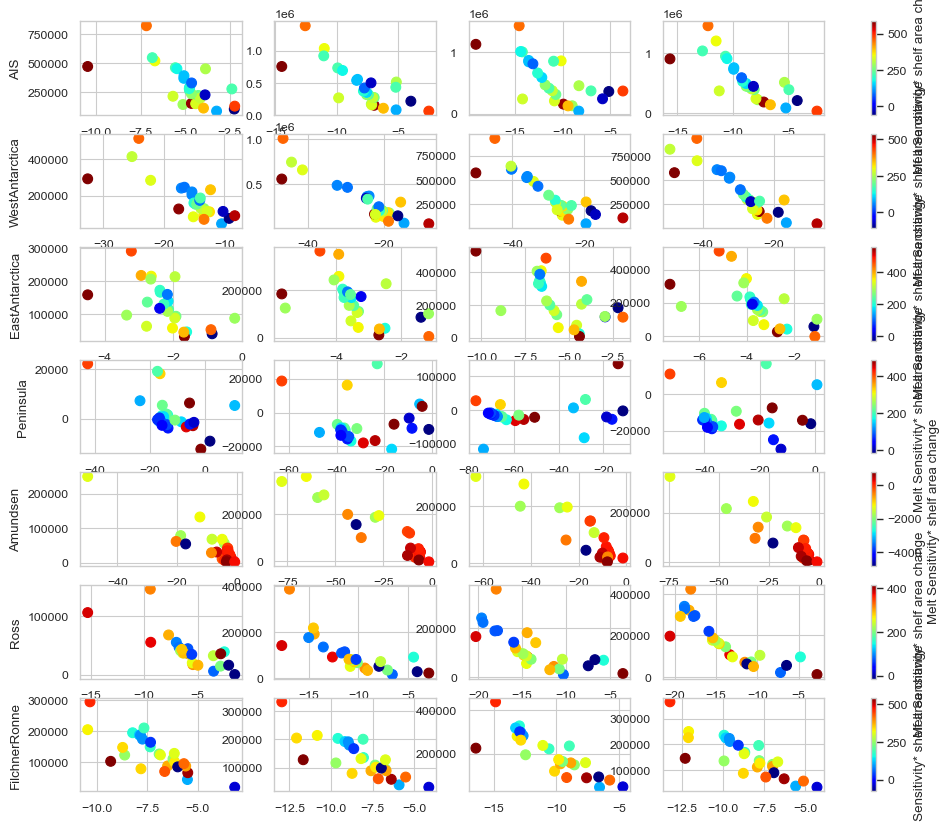

In [9]:
df_iareafl2300_change_mean = df_iareafl2300_change[df_iareafl2300_change.Experiment == 'expAE02']

for i,Model in enumerate(df_iareafl2300_change_mean.Model):
    dm =df_iareafl2300_change[df_iareafl2300_change.Model == Model]
    for j,varname in enumerate(dm.columns[3:]):
        df_iareafl2300_change_mean.iloc[i,j+3] =dm[varname].values.mean()
# df_iareafl2300_change_mean

f,ax2 = plt.subplots(len(regions),len(expnames),figsize = (12,10))
dslr = df_dslr2300
dachange = df_iareagr2300_change
# dachange['Filchner_Ronne']= dachange['FilchnerRonne']

 
df_iareafl2300_change['Filchner_Ronne']= df_iareafl2300_change['FilchnerRonne']
for i,region in enumerate(regions):
    ms = df_best[f'melt_sensetivity_{region}'][:-10]*-1*df_iareafl2300_change_mean[f'{region}'][:-10]
    #get coloarbar
    norm = mcolors.Normalize(vmin=ms.min(), vmax=ms.max())
    sm = plt.cm.ScalarMappable(cmap='jet', norm=norm)
    sm.set_array([])  # Needed for the colorbar
    for j, exp in enumerate(expnames):
        dslr_exp = dslr[dslr.Experiment == exp].reset_index(drop = True)
        dachange_exp = dachange[dachange.Experiment == exp].reset_index(drop = True)
        ax = ax2[i,j]
        # Normalize the melt_sensetivity values and map to colors
        colors = plt.cm.jet(norm(ms))
        
        # Scatter plot with colors based on melt_sensetivity
        scatter = ax.scatter(dachange_exp[region][:-10], dslr_exp[region][:-10], c=colors, s=50)
        
        # Set ylabel for the first column
        if j == 0:
            ax2[i, 0].set_ylabel(region)
    
    # Add a colorbar to each row of plots
    cbar = f.colorbar(sm, ax=ax2[i, :], orientation='vertical')
    cbar.set_label(f'Melt Sensitivity* shelf area change ')
#         ax.scatter(dachange_exp[region],dslr_exp[region])
   
    


### Does cumulative BMB play a role? -- YES but there are some exeptions!


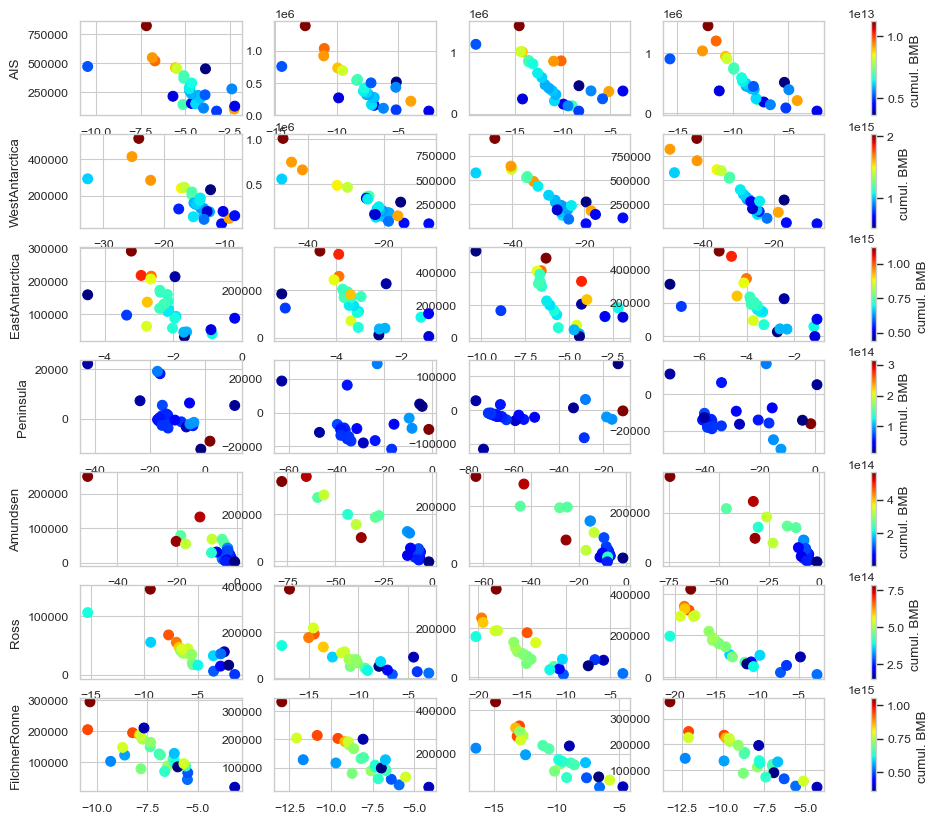

In [10]:
df_cumBMB2300_mean =  df_cumBMB2300[ df_cumBMB2300.Experiment == 'expAE02']

for i,Model in enumerate( df_cumBMB2300_mean.Model):
    dm = df_cumBMB2300[ df_cumBMB2300.Model == Model]
    for j,varname in enumerate(dm.columns[3:]):
         df_cumBMB2300_mean.iloc[i,j+3] =dm[varname].values.mean()
# df_iareafl2300_change_mean

f,ax2 = plt.subplots(len(regions),len(expnames),figsize = (12,10))
dslr = df_dslr2300
dachange = df_iareagr2300_change
# dachange['Filchner_Ronne']= dachange['FilchnerRonne']

 
df_iareafl2300_change['Filchner_Ronne']= df_iareafl2300_change['FilchnerRonne']
for i,region in enumerate(regions):
    ms = df_cumBMB2300_mean[f'{region}'][:-10]
    #get coloarbar
    norm = mcolors.Normalize(vmin=ms.min(), vmax=ms.max())
    sm = plt.cm.ScalarMappable(cmap='jet', norm=norm)
    sm.set_array([])  # Needed for the colorbar
    for j, exp in enumerate(expnames):
        dslr_exp = dslr[dslr.Experiment == exp].reset_index(drop = True)
        dachange_exp = dachange[dachange.Experiment == exp].reset_index(drop = True)
        ax = ax2[i,j]
        # Normalize the melt_sensetivity values and map to colors
        colors = plt.cm.jet(norm(ms))
        
        # Scatter plot with colors based on melt_sensetivity
        scatter = ax.scatter(dachange_exp[region][:-10], dslr_exp[region][:-10], c=colors, s=50)
        
        # Set ylabel for the first column
        if j == 0:
            ax2[i, 0].set_ylabel(region)
    
    # Add a colorbar to each row of plots
    cbar = f.colorbar(sm, ax=ax2[i, :], orientation='vertical')
    cbar.set_label(f'cumul. BMB ')
#         ax.scatter(dachange_exp[region],dslr_exp[region])
   
    

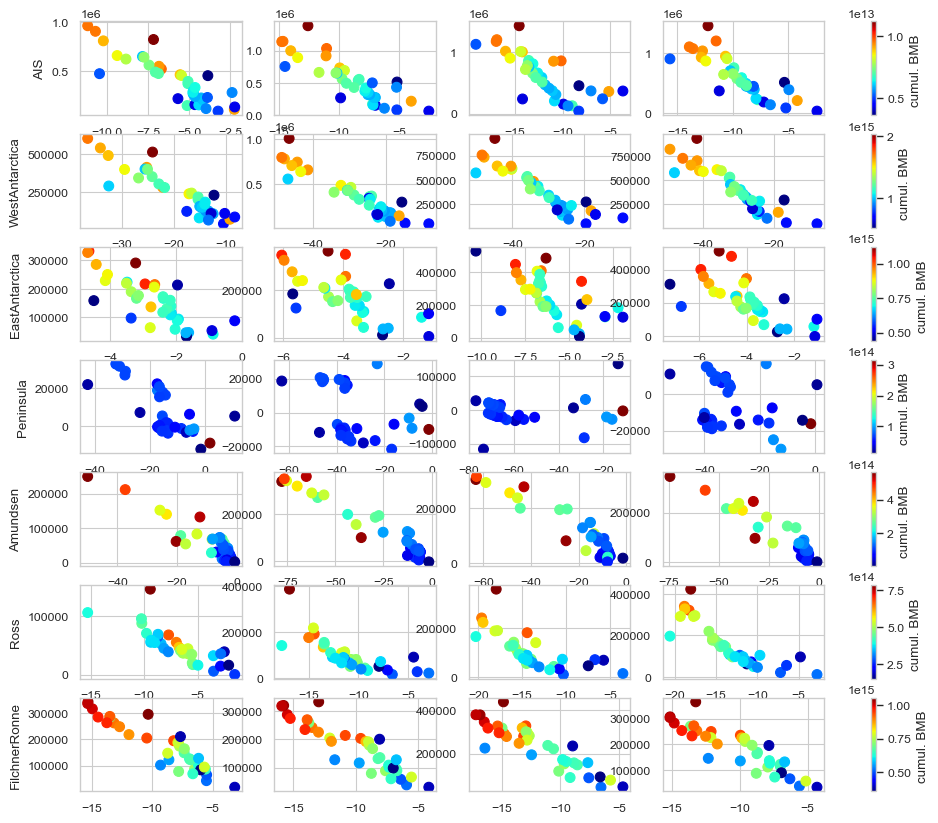

In [11]:
df_cumBMB2300_mean =  df_cumBMB2300[ df_cumBMB2300.Experiment == 'expAE02']

for i,Model in enumerate( df_cumBMB2300_mean.Model):
    dm = df_cumBMB2300[ df_cumBMB2300.Model == Model]
    for j,varname in enumerate(dm.columns[3:]):
         df_cumBMB2300_mean.iloc[i,j+3] =dm[varname].values.mean()
# df_iareafl2300_change_mean

f,ax2 = plt.subplots(len(regions),len(expnames),figsize = (12,10))
dslr = df_dslr2300
dachange = df_iareagr2300_change
# dachange['Filchner_Ronne']= dachange['FilchnerRonne']

 
df_iareafl2300_change['Filchner_Ronne']= df_iareafl2300_change['FilchnerRonne']
for i,region in enumerate(regions):
    ms = df_cumBMB2300_mean[f'{region}']
    norm = mcolors.Normalize(vmin=ms.min(), vmax=ms.max())
    sm = plt.cm.ScalarMappable(cmap='jet', norm=norm)
    sm.set_array([])  # Needed for the colorbar
    for j, exp in enumerate(expnames):
        dslr_exp = dslr[dslr.Experiment == exp].reset_index(drop = True)
        dachange_exp = dachange[dachange.Experiment == exp].reset_index(drop = True)
        ax = ax2[i,j]
        # Normalize the melt_sensetivity values and map to colors
        colors = plt.cm.jet(norm(ms))
        
        # Scatter plot with colors based on melt_sensetivity
        scatter = ax.scatter(dachange_exp[region], dslr_exp[region], c=colors, s=50)
        
        # Set ylabel for the first column
        if j == 0:
            ax2[i, 0].set_ylabel(region)
    
    # Add a colorbar to each row of plots
    cbar = f.colorbar(sm, ax=ax2[i, :], orientation='vertical')
    cbar.set_label(f'cumul. BMB ')
#         ax.scatter(dachange_exp[region],dslr_exp[region])
   
    

## WITH VUW PISM:

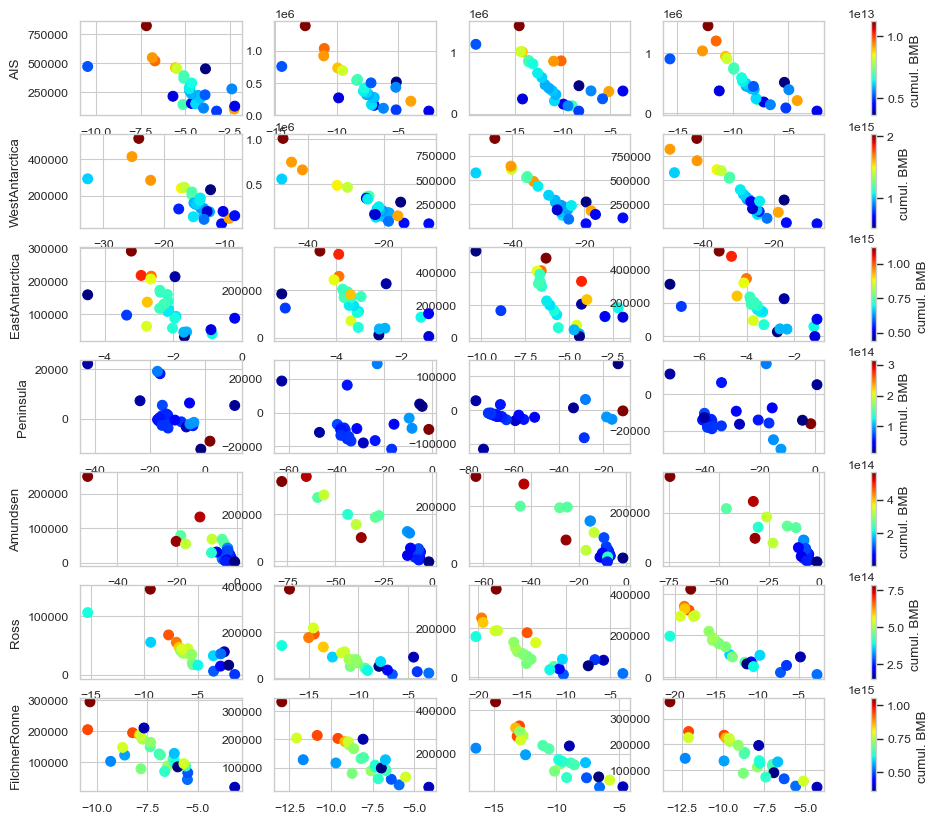

In [13]:
df_cumBMB2300_mean =  df_cumBMB2300[ df_cumBMB2300.Experiment == 'expAE02']

for i,Model in enumerate( df_cumBMB2300_mean.Model):
    dm = df_cumBMB2300[ df_cumBMB2300.Model == Model]
    for j,varname in enumerate(dm.columns[3:]):
         df_cumBMB2300_mean.iloc[i,j+3] =dm[varname].values.mean()
# df_iareafl2300_change_mean

f,ax2 = plt.subplots(len(regions),len(expnames),figsize = (12,10))
dslr = df_dslr2300
dachange = df_iareagr2300_change
# dachange['Filchner_Ronne']= dachange['FilchnerRonne']

 
df_iareafl2300_change['Filchner_Ronne']= df_iareafl2300_change['FilchnerRonne']
for i,region in enumerate(regions):
    ms = df_cumBMB2300_mean[f'{region}'][:-10]
    #get coloarbar
    norm = mcolors.Normalize(vmin=ms.min(), vmax=ms.max())
    sm = plt.cm.ScalarMappable(cmap='jet', norm=norm)
    sm.set_array([])  # Needed for the colorbar
    for j, exp in enumerate(expnames):
        dslr_exp = dslr[dslr.Experiment == exp].reset_index(drop = True)
        dachange_exp = dachange[dachange.Experiment == exp].reset_index(drop = True)
        ax = ax2[i,j]
        # Normalize the melt_sensetivity values and map to colors
        colors = plt.cm.jet(norm(ms))
        
        # Scatter plot with colors based on melt_sensetivity
        scatter = ax.scatter(dachange_exp[region][:-10], dslr_exp[region][:-10], c=colors, s=50)
        
        # Set ylabel for the first column
        if j == 0:
            ax2[i, 0].set_ylabel(region)
    
    # Add a colorbar to each row of plots
    cbar = f.colorbar(sm, ax=ax2[i, :], orientation='vertical')
    cbar.set_label(f'cumul. BMB ')
#         ax.scatter(dachange_exp[region],dslr_exp[region])
   
    

## different SLR over cumulative BMB

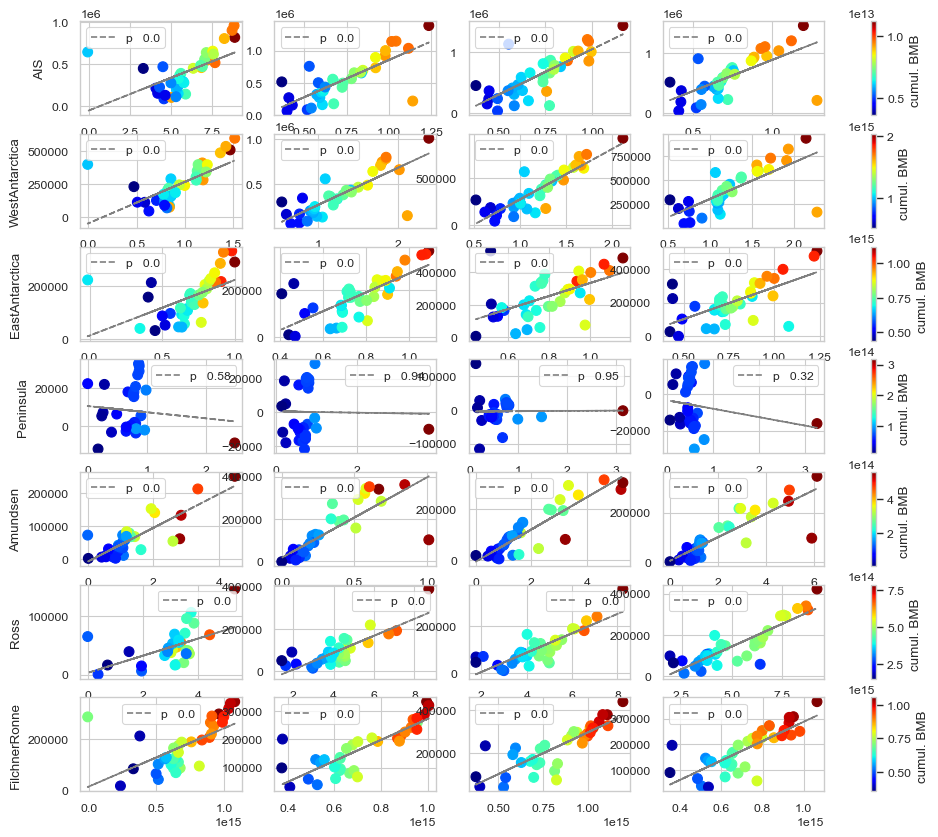

In [14]:
df_cumBMB2300_mean =  df_cumBMB2300[ df_cumBMB2300.Experiment == 'expAE02']

for i,Model in enumerate( df_cumBMB2300_mean.Model):
    dm = df_cumBMB2300[ df_cumBMB2300.Model == Model]
    for j,varname in enumerate(dm.columns[3:]):
         df_cumBMB2300_mean.iloc[i,j+3] =dm[varname].values.mean()
# df_iareafl2300_change_mean

f,ax2 = plt.subplots(len(regions),len(expnames),figsize = (12,10))
dslr = df_dslr2300
dachange = df_cumBMB2300
# dachange['Filchner_Ronne']= dachange['FilchnerRonne']

 
df_iareafl2300_change['Filchner_Ronne']= df_iareafl2300_change['FilchnerRonne']
for i,region in enumerate(regions):
    ms = df_cumBMB2300_mean[f'{region}']
    #get coloarbar
    norm = mcolors.Normalize(vmin=ms.min(), vmax=ms.max())
    sm = plt.cm.ScalarMappable(cmap='jet', norm=norm)
    sm.set_array([])  # Needed for the colorbar
    for j, exp in enumerate(expnames):
        dslr_exp = dslr[dslr.Experiment == exp].reset_index(drop = True)
        dachange_exp = dachange[dachange.Experiment == exp].reset_index(drop = True)
        ax = ax2[i,j]
        # Normalize the melt_sensetivity values and map to colors
        colors = plt.cm.jet(norm(ms))
        
        # Scatter plot with colors based on melt_sensetivity
        scatter = ax.scatter(dachange_exp[region], dslr_exp[region], c=colors, s=50)
        slope, intercept, r, p, se = linregress(dachange_exp[region], dslr_exp[region])
        y= slope *dachange_exp[region] +intercept
        
        ax.plot(dachange_exp[region],y,'--',color = 'gray', label = f'p   {np.round(p,2)}' )
        
        # Set ylabel for the first column
        if j == 0:
            ax2[i, 0].set_ylabel(region)
        ax.legend()
    
    # Add a colorbar to each row of plots
    cbar = f.colorbar(sm, ax=ax2[i, :], orientation='vertical')
    cbar.set_label(f'cumul. BMB ')
#         ax.scatter(dachange_exp[region],dslr_exp[region])
   
    

### same but with  params


In [49]:
params_unique=df_info['Melt parameterisation'].unique()
df_info_exp= df_info[df_info.Experiment == 'expAE02']
unique_scatter = ['^','v','*','s','P','p']
dic_params_scatter = {}
marker_model = []
for i,param in enumerate(params_unique):
    dic_params_scatter[param]=unique_scatter[i]
for key in df_info_exp['Melt parameterisation']:
    marker_model.append( dic_params_scatter[key])
# for i,Model in enumerate( df_cumBMB2300_mean.Model):
# marker_model

/var/folders/ph/m61jd3r90t190p6qvbps3yqct2hr65/T/ipykernel_8196/3736134485.py:39: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  scatter = ax.scatter(xi, dslr_exp[region][k], c=colors[k], marker = marker_model[k],s=50)


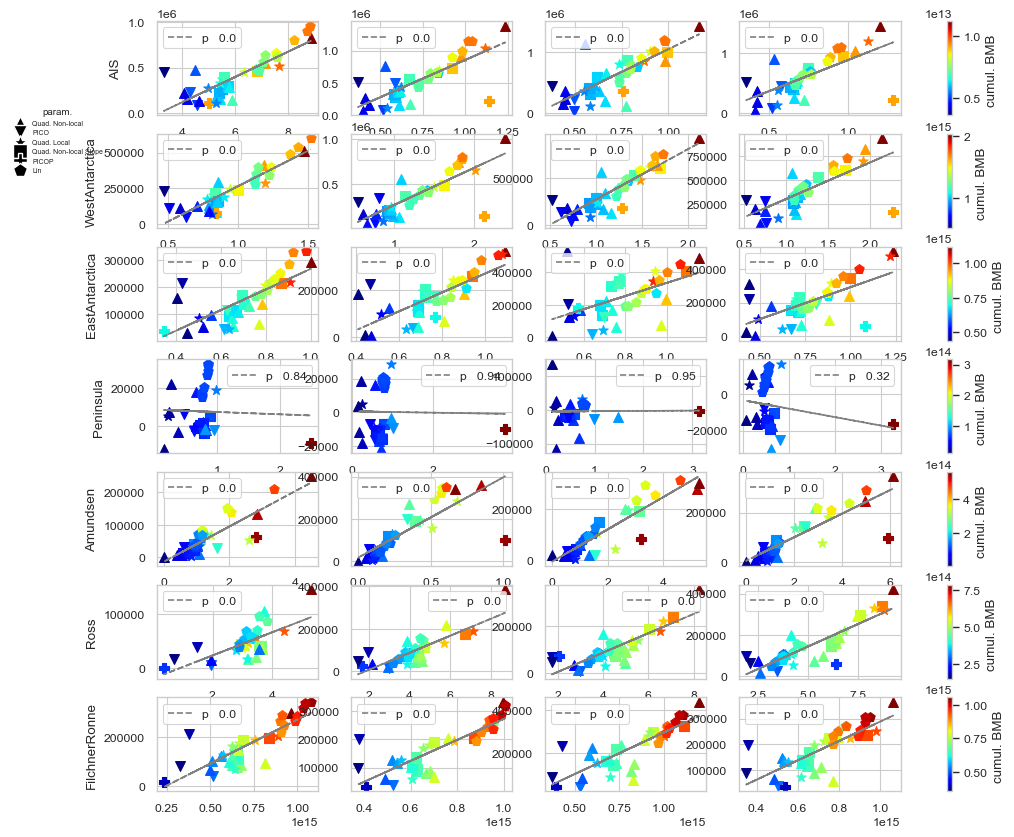

In [51]:
df_cumBMB2300_mean =  df_cumBMB2300[ df_cumBMB2300.Experiment == 'expAE02']

for i,Model in enumerate( df_cumBMB2300_mean.Model):
    dm = df_cumBMB2300[ df_cumBMB2300.Model == Model]
    for j,varname in enumerate(dm.columns[3:]):
         df_cumBMB2300_mean.iloc[i,j+3] =dm[varname].values.mean()
# df_iareafl2300_change_mean
#  Create custom legend elements for parameterizations
legend_elements = [plt.Line2D([0], [0], marker=marker, color='w', label=param,
                              markerfacecolor='black', markersize=10)
                   for param, marker in dic_params_scatter.items()]

f,ax2 = plt.subplots(len(regions),len(expnames),figsize = (12,10))
dslr = df_dslr2300
dachange = df_cumBMB2300
# dachange['Filchner_Ronne']= dachange['FilchnerRonne']


df_iareafl2300_change['Filchner_Ronne']= df_iareafl2300_change['FilchnerRonne']
for i,region in enumerate(regions):
    ms = df_cumBMB2300_mean[f'{region}']
    #get coloarbar
    norm = mcolors.Normalize(vmin=ms.min(), vmax=ms.max())
    sm = plt.cm.ScalarMappable(cmap='jet', norm=norm)
    sm.set_array([])  # Needed for the colorbar
    for j, exp in enumerate(expnames):
        dslr_exp = dslr[dslr.Experiment == exp].reset_index(drop = True)
        dachange_exp = dachange[dachange.Experiment == exp].reset_index(drop = True)
        mvuw = dachange_exp.Model != 'VUW_PISM1_s1'
        ax = ax2[i,j]
        # Normalize the melt_sensetivity values and map to colors
        colors = plt.cm.jet(norm(ms))
        for k,xi in enumerate(dachange_exp[region].values):
        
        # Scatter plot with colors based on melt_sensetivity
            if exp == 'expAE02' and dachange_exp.Model[k] == 'VUW_PISM1_s1':
                continue
            else:
                scatter = ax.scatter(xi, dslr_exp[region][k], c=colors[k], marker = marker_model[k],s=50)
        if exp == 'expAE02':
            x =dachange_exp[region][mvuw]
            slope, intercept, r, p, se = linregress(x, dslr_exp[region][mvuw])
            y= slope *dachange_exp[region][mvuw] +intercept
        else:
            x = dachange_exp[region]
            slope, intercept, r, p, se = linregress(x, dslr_exp[region])
            y= slope *dachange_exp[region] +intercept
        
        ax.plot(x,y,'--',color = 'gray', label = f'p   {np.round(p,2)}' )
        
        # Set ylabel for the first column
        if j == 0:
            ax2[i, 0].set_ylabel(region)
        ax.legend()
    
    # Add a colorbar to each row of plots
    cbar = f.colorbar(sm, ax=ax2[i, :], orientation='vertical')
    cbar.set_label(f'cumul. BMB ')
#         ax.scatter(dachange_exp[region],dslr_exp[region])
f.legend(handles=legend_elements, title='param.', loc='upper left', bbox_to_anchor=(0., 0.8), fontsize=5, title_fontsize=7,frameon=False)
    #     ax[i].plot(Models.index,y)  
    

In [52]:
df_info

,Unnamed: 0,Group,Model,Experiment,Climate Forcing,Model setup,fileID,Main submission,Melt parameterisation,Melt parameters,Resolution,Resolution GL,GL treatment,GL melt,ice front
0,0,DC,ISSM,ctrlAE,ctrl,DC\_ISSM,DC_ISSM,True,Quad. Non-local,AntMean median,4km,4km,Sub-Grid,Sub-Grid,MH
1,1,DC,ISSM,expAE02,CCSM4,DC\_ISSM,DC_ISSM,True,Quad. Non-local,AntMean median,4km,4km,Sub-Grid,Sub-Grid,MH
2,2,DC,ISSM,expAE03,HadGEM2,DC\_ISSM,DC_ISSM,True,Quad. Non-local,AntMean median,4km,4km,Sub-Grid,Sub-Grid,MH
3,3,DC,ISSM,expAE04,CESM2,DC\_ISSM,DC_ISSM,True,Quad. Non-local,AntMean median,4km,4km,Sub-Grid,Sub-Grid,MH
4,4,DC,ISSM,expAE05,UKESM,DC\_ISSM,DC_ISSM,True,Quad. Non-local,AntMean median,4km,4km,Sub-Grid,Sub-Grid,MH
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
210,210,VUW,PISM,ctrlAE,ctrl,VUW\_PISM2\_s4,VUW_PISM2_s4,False,Lin,custom,8km,4km,Yes,Sub-Grid,StR
211,211,VUW,PISM,expAE02,CCSM4,VUW\_PISM2\_s4,VUW_PISM2_s4,False,Lin,custom,8km,4km,Yes,Sub-Grid,StR
212,212,VUW,PISM,expAE03,HadGEM2,VUW\_PISM2\_s4,VUW_PISM2_s4,False,Lin,custom,8km,4km,Yes,Sub-Grid,StR
213,213,VUW,PISM,expAE04,CESM2,VUW\_PISM2\_s4,VUW_PISM2_s4,False,Lin,custom,8km,4km,Yes,Sub-Grid,StR


In [56]:
params_unique=df_info['ice front'].unique()
df_info_exp= df_info[df_info.Experiment == 'expAE02']
unique_scatter = ['^','v','*','s','P','p']
dic_params_scatter = {}
marker_model = []
for i,param in enumerate(params_unique):
    dic_params_scatter[param]=unique_scatter[i]
for key in df_info_exp['ice front']:
    marker_model.append( dic_params_scatter[key])
# for i,Model in enumerate( df_cumBMB2300_mean.Model):
# marker_model

In [57]:
params_unique

array(['MH', 'Fix', 'RO', 'StR', 'VM', 'Div'], dtype=object)

/var/folders/ph/m61jd3r90t190p6qvbps3yqct2hr65/T/ipykernel_8196/3927583182.py:39: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  scatter = ax.scatter(xi, dslr_exp[region][k], c=colors[k], marker = marker_model[k],s=50)


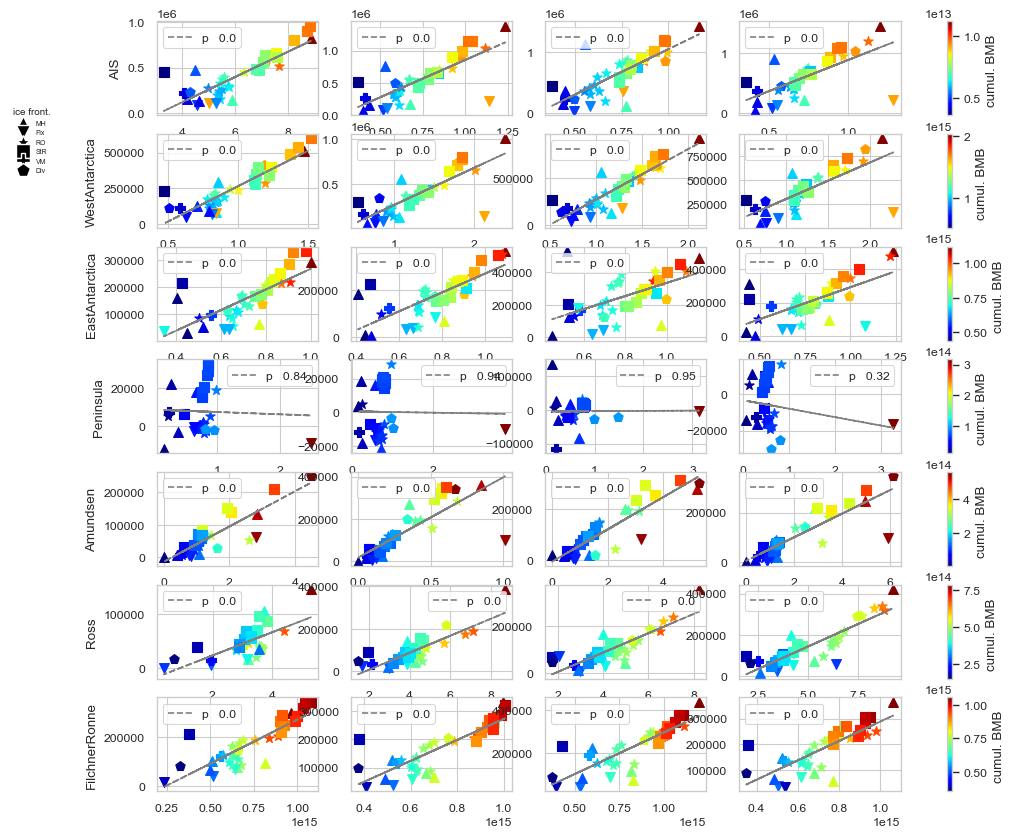

In [58]:
df_cumBMB2300_mean =  df_cumBMB2300[ df_cumBMB2300.Experiment == 'expAE02']

for i,Model in enumerate( df_cumBMB2300_mean.Model):
    dm = df_cumBMB2300[ df_cumBMB2300.Model == Model]
    for j,varname in enumerate(dm.columns[3:]):
         df_cumBMB2300_mean.iloc[i,j+3] =dm[varname].values.mean()
# df_iareafl2300_change_mean
#  Create custom legend elements for parameterizations
legend_elements = [plt.Line2D([0], [0], marker=marker, color='w', label=param,
                              markerfacecolor='black', markersize=10)
                   for param, marker in dic_params_scatter.items()]

f,ax2 = plt.subplots(len(regions),len(expnames),figsize = (12,10))
dslr = df_dslr2300
dachange = df_cumBMB2300
# dachange['Filchner_Ronne']= dachange['FilchnerRonne']


df_iareafl2300_change['Filchner_Ronne']= df_iareafl2300_change['FilchnerRonne']
for i,region in enumerate(regions):
    ms = df_cumBMB2300_mean[f'{region}']
    #get coloarbar
    norm = mcolors.Normalize(vmin=ms.min(), vmax=ms.max())
    sm = plt.cm.ScalarMappable(cmap='jet', norm=norm)
    sm.set_array([])  # Needed for the colorbar
    for j, exp in enumerate(expnames):
        dslr_exp = dslr[dslr.Experiment == exp].reset_index(drop = True)
        dachange_exp = dachange[dachange.Experiment == exp].reset_index(drop = True)
        mvuw = dachange_exp.Model != 'VUW_PISM1_s1'
        ax = ax2[i,j]
        # Normalize the melt_sensetivity values and map to colors
        colors = plt.cm.jet(norm(ms))
        for k,xi in enumerate(dachange_exp[region].values):
        
        # Scatter plot with colors based on melt_sensetivity
            if exp == 'expAE02' and dachange_exp.Model[k] == 'VUW_PISM1_s1':
                continue
            else:
                scatter = ax.scatter(xi, dslr_exp[region][k], c=colors[k], marker = marker_model[k],s=50)
        if exp == 'expAE02':
            x =dachange_exp[region][mvuw]
            slope, intercept, r, p, se = linregress(x, dslr_exp[region][mvuw])
            y= slope *dachange_exp[region][mvuw] +intercept
        else:
            x = dachange_exp[region]
            slope, intercept, r, p, se = linregress(x, dslr_exp[region])
            y= slope *dachange_exp[region] +intercept
        
        ax.plot(x,y,'--',color = 'gray', label = f'p   {np.round(p,2)}' )
        
        # Set ylabel for the first column
        if j == 0:
            ax2[i, 0].set_ylabel(region)
        ax.legend()
    
    # Add a colorbar to each row of plots
    cbar = f.colorbar(sm, ax=ax2[i, :], orientation='vertical')
    cbar.set_label(f'cumul. BMB ')
#         ax.scatter(dachange_exp[region],dslr_exp[region])
f.legend(handles=legend_elements, title='ice front.', loc='upper left', bbox_to_anchor=(0., 0.8), fontsize=5, title_fontsize=7,frameon=False)
    #     ax[i].plot(Models.index,y)  
    

In [42]:
mvuw = dachange_exp.Model != 'VUW_PISM1_s1'

In [45]:
dachange_exp[region][mvuw]

0     5886750228480
1     4564567195648
2     8876182208512
3     4186299695104
4     4501446066176
5     5431658283008
6     7675498201088
7     6845922017280
8     5381230690304
9     5327263629312
10    6350687436800
11    5505756430336
12    5383078805504
13    5527436787712
14    5599536873472
15    5734687834112
16    5780834615296
17    5445592809472
18    3307881365504
19    4076464504832
20    5023297699840
21    4299998101504
22    7153614061568
23    4990137008128
24    5296837623808
25    4642454896640
26    7042872377344
28    6801960992768
29    6905187008512
30    7144425390080
31    8242729058304
32    8714480254976
33    7538897584128
34    7579907391488
35    8837367070720
Name: AIS, dtype: int64

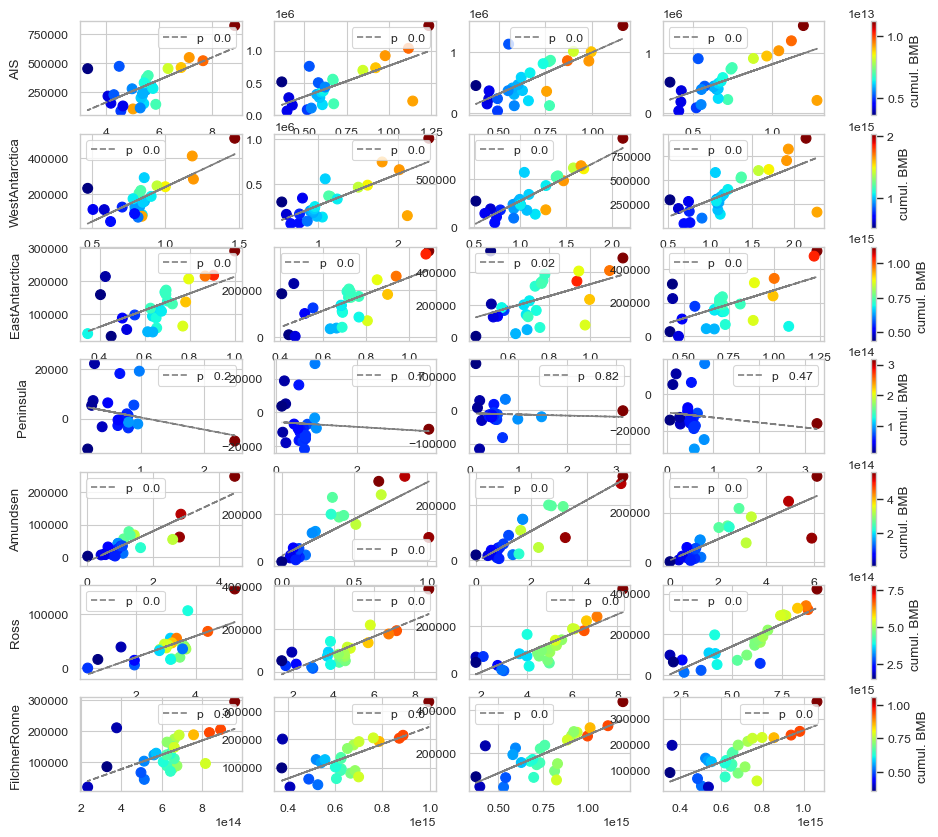

In [62]:
## different SLR over cumulative BMB = no vuw pism

df_cumBMB2300_mean =  df_cumBMB2300[ df_cumBMB2300.Experiment == 'expAE02']

for i,Model in enumerate( df_cumBMB2300_mean.Model):
    dm = df_cumBMB2300[ df_cumBMB2300.Model == Model]
    for j,varname in enumerate(dm.columns[3:]):
         df_cumBMB2300_mean.iloc[i,j+3] =dm[varname].values.mean()
# df_iareafl2300_change_mean

f,ax2 = plt.subplots(len(regions),len(expnames),figsize = (12,10))
dslr = df_dslr2300
dachange = df_cumBMB2300
# dachange['Filchner_Ronne']= dachange['FilchnerRonne']

 
df_iareafl2300_change['Filchner_Ronne']= df_iareafl2300_change['FilchnerRonne']
for i,region in enumerate(regions):
    ms = df_cumBMB2300_mean[f'{region}'][:-10]
    #get coloarbar
    norm = mcolors.Normalize(vmin=ms.min(), vmax=ms.max())
    sm = plt.cm.ScalarMappable(cmap='jet', norm=norm)
    sm.set_array([])  # Needed for the colorbar
    for j, exp in enumerate(expnames):
        dslr_exp = dslr[dslr.Experiment == exp].reset_index(drop = True)
        dachange_exp = dachange[dachange.Experiment == exp].reset_index(drop = True)
        ax = ax2[i,j]
        # Normalize the melt_sensetivity values and map to colors
        colors = plt.cm.jet(norm(ms))
        
        # Scatter plot with colors based on melt_sensetivity
        scatter = ax.scatter(dachange_exp[region][:-10], dslr_exp[region][:-10], c=colors, s=50)
        slope, intercept, r, p, se = linregress(dachange_exp[region][:-10], dslr_exp[region][:-10])
        y= slope *dachange_exp[region][:-10] +intercept
        
        ax.plot(dachange_exp[region][:-10],y,'--',color = 'gray', label = f'p   {np.round(p,2)}' )
        
        # Set ylabel for the first column
        if j == 0:
            ax2[i, 0].set_ylabel(region)
        ax.legend()
    
        
      
    
    # Add a colorbar to each row of plots
    cbar = f.colorbar(sm, ax=ax2[i, :], orientation='vertical')
    cbar.set_label(f'cumul. BMB ')
#         ax.scatter(dachange_exp[region],dslr_exp[region])
   
    

## different grounded area over cumulative BMB

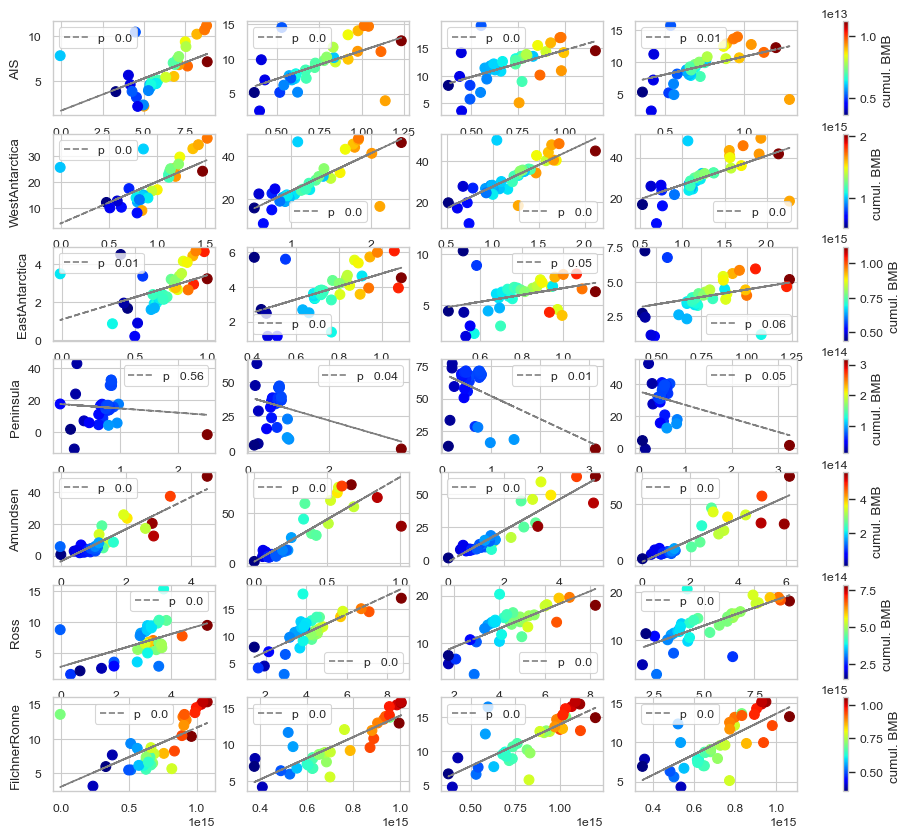

In [63]:
df_cumBMB2300_mean =  df_cumBMB2300[ df_cumBMB2300.Experiment == 'expAE02']

for i,Model in enumerate( df_cumBMB2300_mean.Model):
    dm = df_cumBMB2300[ df_cumBMB2300.Model == Model]
    for j,varname in enumerate(dm.columns[3:]):
         df_cumBMB2300_mean.iloc[i,j+3] =dm[varname].values.mean()
# df_iareafl2300_change_mean

f,ax2 = plt.subplots(len(regions),len(expnames),figsize = (12,10))
dslr = df_iareagr2300_change
dachange = df_cumBMB2300
# dachange['Filchner_Ronne']= dachange['FilchnerRonne']

 
df_iareafl2300_change['Filchner_Ronne']= df_iareafl2300_change['FilchnerRonne']
for i,region in enumerate(regions):
    ms = df_cumBMB2300_mean[f'{region}']
    #get coloarbar
    norm = mcolors.Normalize(vmin=ms.min(), vmax=ms.max())
    sm = plt.cm.ScalarMappable(cmap='jet', norm=norm)
    sm.set_array([])  # Needed for the colorbar
    for j, exp in enumerate(expnames):
        dslr_exp = dslr[dslr.Experiment == exp].reset_index(drop = True)
        dachange_exp = dachange[dachange.Experiment == exp].reset_index(drop = True)
        ax = ax2[i,j]
        # Normalize the melt_sensetivity values and map to colors
        colors = plt.cm.jet(norm(ms))
        
        # Scatter plot with colors based on melt_sensetivity
        scatter = ax.scatter(dachange_exp[region], -1*dslr_exp[region], c=colors, s=50)
        slope, intercept, r, p, se = linregress(dachange_exp[region], -1*dslr_exp[region])
        y= slope *dachange_exp[region] +intercept
        
        ax.plot(dachange_exp[region],y,'--',color = 'gray', label = f'p   {np.round(p,2)}' )
        
        # Set ylabel for the first column
        if j == 0:
            ax2[i, 0].set_ylabel(region)
        ax.legend()
    
    # Add a colorbar to each row of plots
    cbar = f.colorbar(sm, ax=ax2[i, :], orientation='vertical')
    cbar.set_label(f'cumul. BMB ')
#         ax.scatter(dachange_exp[region],dslr_exp[region])
   
    

### now view pism

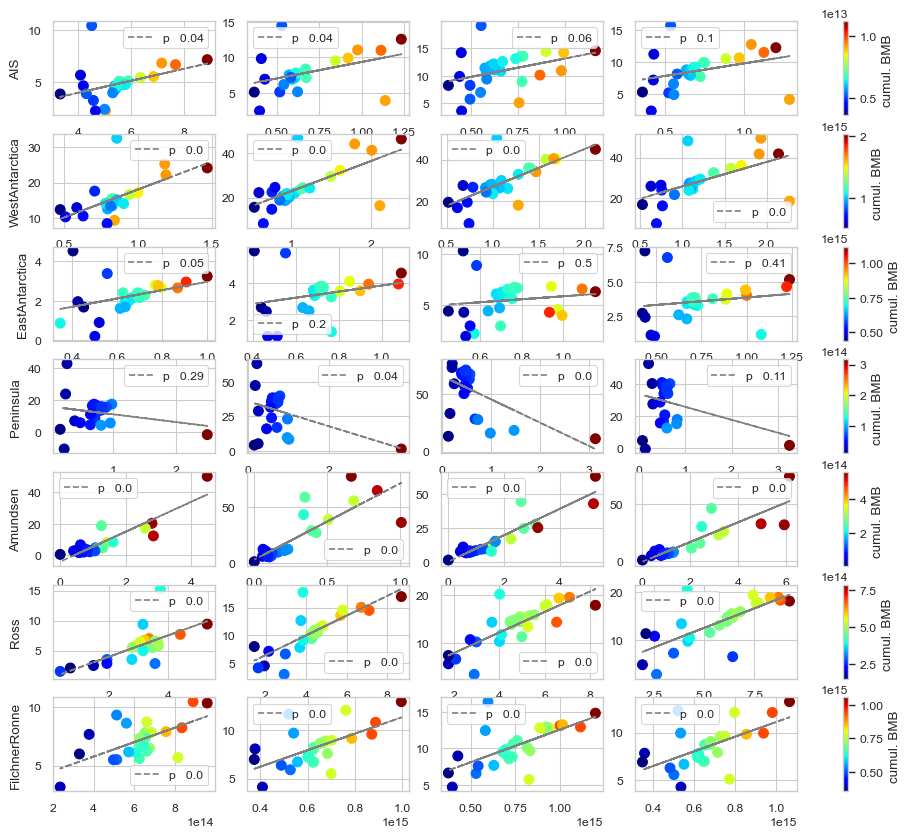

In [64]:
df_cumBMB2300_mean =  df_cumBMB2300[ df_cumBMB2300.Experiment == 'expAE02']

for i,Model in enumerate( df_cumBMB2300_mean.Model):
    dm = df_cumBMB2300[ df_cumBMB2300.Model == Model]
    for j,varname in enumerate(dm.columns[3:]):
         df_cumBMB2300_mean.iloc[i,j+3] =dm[varname].values.mean()
# df_iareafl2300_change_mean

f,ax2 = plt.subplots(len(regions),len(expnames),figsize = (12,10))
dslr = df_iareagr2300_change
dachange = df_cumBMB2300
# dachange['Filchner_Ronne']= dachange['FilchnerRonne']

 
df_iareafl2300_change['Filchner_Ronne']= df_iareafl2300_change['FilchnerRonne']
for i,region in enumerate(regions):
    ms = df_cumBMB2300_mean[f'{region}'][:-10]
    #get coloarbar
    norm = mcolors.Normalize(vmin=ms.min(), vmax=ms.max())
    sm = plt.cm.ScalarMappable(cmap='jet', norm=norm)
    sm.set_array([])  # Needed for the colorbar
    for j, exp in enumerate(expnames):
        dslr_exp = dslr[dslr.Experiment == exp].reset_index(drop = True)
        dachange_exp = dachange[dachange.Experiment == exp].reset_index(drop = True)
        ax = ax2[i,j]
        # Normalize the melt_sensetivity values and map to colors
        colors = plt.cm.jet(norm(ms))
        
        # Scatter plot with colors based on melt_sensetivity
        scatter = ax.scatter(dachange_exp[region][:-10], -1*dslr_exp[region][:-10], c=colors, s=50)
        slope, intercept, r, p, se = linregress(dachange_exp[region][:-10], -1*dslr_exp[region][:-10])
        y= slope *dachange_exp[region][:-10] +intercept
        
        ax.plot(dachange_exp[region][:-10],y,'--',color = 'gray', label = f'p   {np.round(p,2)}' )
        
        # Set ylabel for the first column
        if j == 0:
            ax2[i, 0].set_ylabel(region)
        ax.legend()
    
    # Add a colorbar to each row of plots
    cbar = f.colorbar(sm, ax=ax2[i, :], orientation='vertical')
    cbar.set_label(f'cumul. BMB ')
#         ax.scatter(dachange_exp[region],dslr_exp[region])
   
    

In [65]:
slope

7.692974358878234e-15

In [66]:
dachange_exp[region].values

array([ 680670283669120,  502378633971712, 1065172807399808,
        483485307472384,  522471718063104,  714912525655200,
        981465118455808,  938853412710912,  650962185367552,
        645418698598400,  855412586324480,  622589808569344,
        616385125977088,  728274226477056,  751048821488640,
        656128631717888,  651821560445952,  681476003119104,
        359401765054464,  534996940001280,  536569053175808,
        349162011079168,  797495972923904,  551286001356288,
        617941356908032,  772954606537216,  798567378214016,
        832703450535168,  773281567227104,  774249201705216,
        833121878479456,  928962021093184,  950448574379712,
        904953749293184,  894065372338432,  930142102729152])

###  again dyn slr gr. area retreat

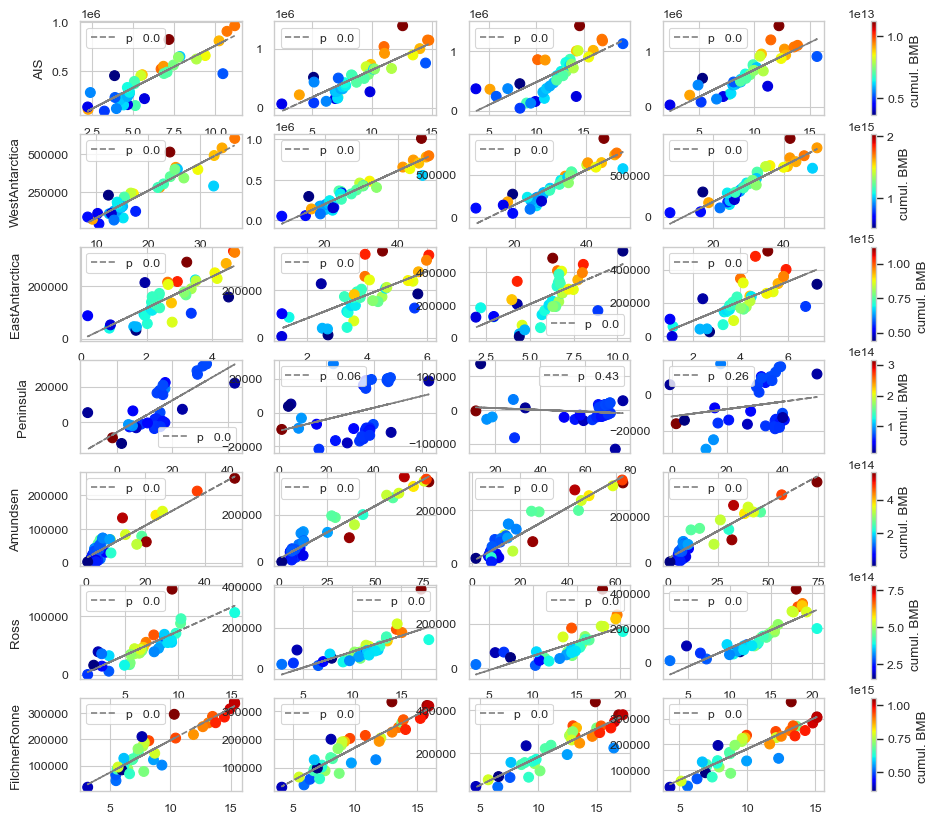

In [67]:
df_cumBMB2300_mean =  df_cumBMB2300[ df_cumBMB2300.Experiment == 'expAE02']

for i,Model in enumerate( df_cumBMB2300_mean.Model):
    dm = df_cumBMB2300[ df_cumBMB2300.Model == Model]
    for j,varname in enumerate(dm.columns[3:]):
         df_cumBMB2300_mean.iloc[i,j+3] =dm[varname].values.mean()
# df_iareafl2300_change_mean

f,ax2 = plt.subplots(len(regions),len(expnames),figsize = (12,10))
dslr = df_dslr2300
dachange = df_iareagr2300_change
# dachange['Filchner_Ronne']= dachange['FilchnerRonne']

 
df_iareafl2300_change['Filchner_Ronne']= df_iareafl2300_change['FilchnerRonne']
for i,region in enumerate(regions):
    ms = df_cumBMB2300_mean[f'{region}']
    #get coloarbar
    norm = mcolors.Normalize(vmin=ms.min(), vmax=ms.max())
    sm = plt.cm.ScalarMappable(cmap='jet', norm=norm)
    sm.set_array([])  # Needed for the colorbar
    for j, exp in enumerate(expnames):
        dslr_exp = dslr[dslr.Experiment == exp].reset_index(drop = True)
        dachange_exp = dachange[dachange.Experiment == exp].reset_index(drop = True)
        ax = ax2[i,j]
        # Normalize the melt_sensetivity values and map to colors
        colors = plt.cm.jet(norm(ms))
        
        # Scatter plot with colors based on melt_sensetivity
        scatter = ax.scatter(-1*dachange_exp[region],dslr_exp[region], c=colors, s=50)
        slope, intercept, r, p, se = linregress(-1*dachange_exp[region], dslr_exp[region])
        y= -1*slope*dachange_exp[region] +intercept
        
        ax.plot(-1*dachange_exp[region],y,'--',color = 'gray', label = f'p   {np.round(p,2)}' )
        
        # Set ylabel for the first column
        if j == 0:
            ax2[i, 0].set_ylabel(region)
        ax.legend()
    
    # Add a colorbar to each row of plots
    cbar = f.colorbar(sm, ax=ax2[i, :], orientation='vertical')
    cbar.set_label(f'cumul. BMB ')
#         ax.scatter(dachange_exp[region],dslr_exp[region])
   
    

In [ ]:
df_cumBMB2300_mean =  df_cumBMB2300[ df_cumBMB2300.Experiment == 'expAE02']

for i,Model in enumerate( df_cumBMB2300_mean.Model):
    dm = df_cumBMB2300[ df_cumBMB2300.Model == Model]
    for j,varname in enumerate(dm.columns[3:]):
         df_cumBMB2300_mean.iloc[i,j+3] =dm[varname].values.mean()
# df_iareafl2300_change_mean

f,ax2 = plt.subplots(len(regions),len(expnames),figsize = (12,10))
dslr = df_dslr2300
dachange = df_iareagr2300_change
# dachange['Filchner_Ronne']= dachange['FilchnerRonne']

 
df_iareafl2300_change['Filchner_Ronne']= df_iareafl2300_change['FilchnerRonne']
for i,region in enumerate(regions):
    ms = df_cumBMB2300_mean[f'{region}']
    #get coloarbar
    norm = mcolors.Normalize(vmin=ms.min(), vmax=ms.max())
    sm = plt.cm.ScalarMappable(cmap='jet', norm=norm)
    sm.set_array([])  # Needed for the colorbar
    for j, exp in enumerate(expnames):
        dslr_exp = dslr[dslr.Experiment == exp].reset_index(drop = True)
        dachange_exp = dachange[dachange.Experiment == exp].reset_index(drop = True)
        ax = ax2[i,j]
        # Normalize the melt_sensetivity values and map to colors
        colors = plt.cm.jet(norm(ms))
        
        # Scatter plot with colors based on melt_sensetivity
        scatter = ax.scatter(-1*dachange_exp[region],dslr_exp[region], c=colors, s=50)
        slope, intercept, r, p, se = linregress(-1*dachange_exp[region], dslr_exp[region])
        y= -1*slope*dachange_exp[region] +intercept
        
        ax.plot(-1*dachange_exp[region],y,'--',color = 'gray', label = f'p   {np.round(p,2)}' )
        
        # Set ylabel for the first column
        if j == 0:
            ax2[i, 0].set_ylabel(region)
        ax.legend()
    
    # Add a colorbar to each row of plots
    cbar = f.colorbar(sm, ax=ax2[i, :], orientation='vertical')
    cbar.set_label(f'cumul. BMB ')
#         ax.scatter(dachange_exp[region],dslr_exp[region])
   
    